# MDN: Mixture Density Network for SLA Forecasting

**Architecture:** GRU(64) backbone + K=3 Gaussian Mixture output  
**Loss:** Negative log-likelihood of Gaussian mixture (Bishop, 1994)  
**PI:** Monte Carlo sampling (5000 samples) → 2.5%/97.5% quantiles → 95% PI  
**Advantage:** Models multi-modal and heteroscedastic uncertainty

In [2]:
# Cell 1 — Environment
RUN_ENV  = 'local'
BASE_DIR = r'c:\Users\DA IICT K\Desktop\BMP_files'
if RUN_ENV == 'colab':
    from google.colab import drive; drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/BMP_Data/'

import os, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.preprocessing import RobustScaler
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

DATA_FILE = os.path.join(BASE_DIR, 'sla_daily_indian_ocean_2021_2023.nc')
SAVE_DIR  = os.path.join(BASE_DIR, 'results_IndianOcean/')
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'TF {tf.__version__}')

TF 2.21.0


In [4]:
# Cell 2 — Config + Data
LOCATIONS = {
    'Arabian_Sea':   (15.0, 65.0),
    'Bay_of_Bengal': (12.0, 87.0),
    'Andaman_Sea':   (11.0, 95.0),
    'Lakshadweep':   (10.0, 73.0),
    'South_IO':      (-5.0, 75.0),
}
TRAIN_SPLIT = 0.80
SEQ_LEN     = 30
EPOCHS      = 100
BATCH_SIZE  = 64
LR          = 0.001
PATIENCE    = 20
SEEDS       = [42, 7, 13, 99, 2025]
DROPOUT     = 0.2
K_COMPONENTS = 3   # Gaussian mixture components
ALPHA_WIS    = 0.20
TARGET_PICP  = 0.95

ds = xr.open_dataset(DATA_FILE)
times_index = pd.to_datetime(ds['time'].values)

def get_data(loc_name):
    lat, lon = LOCATIONS[loc_name]
    sla = ds['sla'].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    s = pd.Series(sla, index=times_index).interpolate(method='time',limit=14).ffill().bfill().values
    n=len(s); n_train=int(n*TRAIN_SPLIT); n_test=n-n_train
    sc = RobustScaler()
    tr = sc.fit_transform(s[:n_train].reshape(-1,1)).flatten()
    te = sc.transform(s[n_train:].reshape(-1,1)).flatten()
    comb = np.concatenate([tr, te])
    X_tr = np.array([tr[i:i+SEQ_LEN] for i in range(len(tr)-SEQ_LEN)])[..., np.newaxis]
    y_tr = np.array([tr[i+SEQ_LEN]   for i in range(len(tr)-SEQ_LEN)])
    X_te = np.array([comb[n_train-SEQ_LEN+i:n_train+i] for i in range(n_test)])[..., np.newaxis]
    y_te = np.array([comb[n_train+i] for i in range(n_test)])
    return X_tr, y_tr, X_te, y_te, sc, n_test

def winkler_score(yt, lo, hi, alpha=ALPHA_WIS):
    return float(np.mean((hi-lo)+(2/alpha)*np.maximum(0,lo-yt)+(2/alpha)*np.maximum(0,yt-hi)))
def cwc(picp, mpiw, target=TARGET_PICP, eta=50):
    return mpiw if picp>=target else mpiw*np.exp(-eta*(picp-target))
def full_metrics(yt_m, lo_m, hi_m):
    lo=np.minimum(lo_m,hi_m); hi=np.maximum(lo_m,hi_m)
    picp=float(np.mean((yt_m>=lo)&(yt_m<=hi)))
    mpiw=float(np.mean(hi-lo))
    return picp*100, mpiw, winkler_score(yt_m,lo,hi), cwc(picp,mpiw)

print("Config ready.")

Config ready.


In [6]:
# Cell 3 — MDN Model
# Reference: Bishop (1994) "Mixture Density Networks"
# For K=3 components, output size = K (pi) + K (mu) + K (sigma) = 9

class MDNOutputLayer(layers.Layer):
    """
    Mixture Density Network output layer.
    Produces K mixture weights (pi), K means (mu), K std devs (sigma).
    Uses softmax(pi) + softplus(sigma) to ensure valid distributions.
    """
    def __init__(self, k, **kwargs):
        super().__init__(**kwargs)
        self.k = k
        self.pi_dense    = layers.Dense(k, name='pi')
        self.mu_dense    = layers.Dense(k, name='mu')
        self.sigma_dense = layers.Dense(k, name='sigma')

    def call(self, x):
        pi    = tf.nn.softmax(self.pi_dense(x)) + 1e-8      # weights sum to 1
        mu    = self.mu_dense(x)                             # unconstrained means
        sigma = tf.nn.softplus(self.sigma_dense(x)) + 1e-5  # positive std devs
        return tf.concat([pi, mu, sigma], axis=-1)

def build_mdn_model(seq_len=SEQ_LEN, k=K_COMPONENTS, dropout=DROPOUT):
    inp = keras.Input(shape=(seq_len, 1))
    x   = layers.GRU(64, activation='tanh')(inp)
    x   = layers.Dropout(dropout)(x)
    x   = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    out = MDNOutputLayer(k)(x)
    return keras.Model(inp, out)

def mdn_nll_loss(k=K_COMPONENTS):
    """
    Negative log-likelihood for Gaussian mixture.
    y_true: (N, 2) duplicated target
    y_pred: (N, 3K) = [pi1..piK, mu1..muK, sig1..sigK]
    """
    def loss(y_true, y_pred):
        true = y_true[:, 0:1]
        pi   = y_pred[:, :k]
        mu   = y_pred[:, k:2*k]
        sig  = y_pred[:, 2*k:3*k]
        log_pi   = tf.math.log(pi)
        log_norm = (-0.5*tf.square((true-mu)/sig)
                    - tf.math.log(sig)
                    - 0.5*tf.cast(tf.math.log(2*np.pi), tf.float32))
        log_mix  = tf.reduce_logsumexp(log_pi + log_norm, axis=1)
        return -tf.reduce_mean(log_mix)
    return loss

def mdn_sample_quantiles(y_pred_raw, scaler, k=K_COMPONENTS, n_samples=5000, q_lo=0.025, q_hi=0.975):
    """
    Monte Carlo sampling from predicted mixture -> 95% prediction intervals.
    Returns lo_m, hi_m in metres.
    """
    pi  = y_pred_raw[:, :k]
    mu  = y_pred_raw[:, k:2*k]
    sig = y_pred_raw[:, 2*k:3*k]
    pi  = pi / pi.sum(axis=1, keepdims=True)   # re-normalize

    los, his = [], []
    for i in range(len(y_pred_raw)):
        idx  = np.random.choice(k, size=n_samples, p=pi[i])
        samp = np.random.normal(mu[i, idx], np.abs(sig[i, idx]))
        lo_s = float(np.quantile(samp, q_lo))
        hi_s = float(np.quantile(samp, q_hi))
        lo_m = float(scaler.inverse_transform([[lo_s]])[0, 0])
        hi_m = float(scaler.inverse_transform([[hi_s]])[0, 0])
        los.append(lo_m); his.append(hi_m)
    return np.array(los), np.array(his)

print(f"MDN model: K={K_COMPONENTS} components, output size={3*K_COMPONENTS}")
print("q_lo=0.025, q_hi=0.975 → 95% PI from mixture sampling")

MDN model: K=3 components, output size=9
q_lo=0.025, q_hi=0.975 → 95% PI from mixture sampling


In [7]:
# Cell 4 — Training Loop
mdn_results = []

for loc_name in LOCATIONS:
    print(f"\n{'#'*55}")
    print(f"  MDN @ {loc_name}")
    print(f"{'#'*55}")
    X_tr, y_tr, X_te, y_te, scaler, n_test = get_data(loc_name)
    lat, lon = LOCATIONS[loc_name]
    y_dup = np.hstack([y_tr.reshape(-1,1), y_tr.reshape(-1,1)])
    seed_picps, seed_mpiws, seed_wis, seed_cwc = [], [], [], []

    for seed in SEEDS:
        tf.random.set_seed(seed); np.random.seed(seed)
        m = build_mdn_model()
        m.compile(optimizer=keras.optimizers.Adam(LR, clipnorm=1.0),
                  loss=mdn_nll_loss(K_COMPONENTS))
        cbs = [
            keras.callbacks.EarlyStopping(patience=PATIENCE, restore_best_weights=True, verbose=0),
            keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6, verbose=0)
        ]
        m.fit(X_tr, y_dup, epochs=EPOCHS, batch_size=BATCH_SIZE,
              validation_split=0.10, callbacks=cbs, verbose=0)

        raw  = m.predict(X_te, verbose=0)
        lo_m, hi_m = mdn_sample_quantiles(raw, scaler, k=K_COMPONENTS)
        y_m  = scaler.inverse_transform(y_te.reshape(-1,1)).flatten()
        picp, mpiw, wis, cwc_ = full_metrics(y_m, lo_m, hi_m)
        seed_picps.append(picp); seed_mpiws.append(mpiw)
        seed_wis.append(wis); seed_cwc.append(cwc_)
        print(f"  seed={seed:4d} | PICP={picp:.1f}% | MPIW={mpiw:.5f}")

    avg_p=np.mean(seed_picps); std_p=np.std(seed_picps)
    avg_m=np.mean(seed_mpiws); std_m=np.std(seed_mpiws)
    avg_w=np.mean(seed_wis);   std_w=np.std(seed_wis)
    avg_c=np.mean(seed_cwc);   std_c=np.std(seed_cwc)
    print(f"  PICP={avg_p:.1f}±{std_p:.1f}%  MPIW={avg_m:.5f}  WIS={avg_w:.5f}  CWC={avg_c:.5f}")
    mdn_results.append(dict(
        location=loc_name, lat=lat, lon=lon, model=f'MDN-GRU-K{K_COMPONENTS}',
        avg_picp=avg_p, std_picp=std_p, avg_mpiw=avg_m, std_mpiw=std_m,
        avg_wis=avg_w, std_wis=std_w, avg_cwc=avg_c, std_cwc=std_c,
        n_seeds=len(SEEDS), n_train_seqs=len(X_tr), n_test_pts=n_test, seq_len=SEQ_LEN,
        k_components=K_COMPONENTS
    ))

df_mdn = pd.DataFrame(mdn_results)
df_mdn.to_csv(os.path.join(SAVE_DIR, 'results_MDN_IO.csv'), index=False)
print(f"\nSaved: results_MDN_IO.csv")
print(df_mdn[['location','avg_picp','std_picp','avg_mpiw','avg_cwc']].to_string(index=False))


#######################################################
  MDN @ Arabian_Sea
#######################################################
  seed=  42 | PICP=100.0% | MPIW=0.01856
  seed=   7 | PICP=100.0% | MPIW=0.01910
  seed=  13 | PICP=100.0% | MPIW=0.02050
  seed=  99 | PICP=100.0% | MPIW=0.01978
  seed=2025 | PICP=100.0% | MPIW=0.02044
  PICP=100.0±0.0%  MPIW=0.01968  WIS=0.01968  CWC=0.01968

#######################################################
  MDN @ Bay_of_Bengal
#######################################################
  seed=  42 | PICP=100.0% | MPIW=0.01563
  seed=   7 | PICP=100.0% | MPIW=0.01768
  seed=  13 | PICP=100.0% | MPIW=0.01532
  seed=  99 | PICP=99.5% | MPIW=0.01686
  seed=2025 | PICP=100.0% | MPIW=0.01904
  PICP=99.9±0.2%  MPIW=0.01691  WIS=0.01691  CWC=0.01691

#######################################################
  MDN @ Andaman_Sea
#######################################################
  seed=  42 | PICP=100.0% | MPIW=0.02253
  seed=   7 | PICP=98.6% | MPIW=0.

In [12]:
# Cell 4 — Training Loop
mdn_results = []
all_preds = {} # <--- ADDED: Initialize dictionary to save bounds for plotting

for loc_name in LOCATIONS:
    print(f"\n{'#'*55}")
    print(f"  MDN @ {loc_name}")
    print(f"{'#'*55}")
    X_tr, y_tr, X_te, y_te, scaler, n_test = get_data(loc_name)
    lat, lon = LOCATIONS[loc_name]
    y_dup = np.hstack([y_tr.reshape(-1,1), y_tr.reshape(-1,1)])
    seed_picps, seed_mpiws, seed_wis, seed_cwc = [], [], [], []

    # <--- ADDED: Prepare dictionary structure for this location
    all_preds[loc_name] = {}
    model_id = f'MDN-GRU-K{K_COMPONENTS}'
    all_preds[loc_name][model_id] = {}

    for seed in SEEDS:
        tf.random.set_seed(seed); np.random.seed(seed)
        m = build_mdn_model()
        m.compile(optimizer=keras.optimizers.Adam(LR, clipnorm=1.0),
                  loss=mdn_nll_loss(K_COMPONENTS))
        cbs = [
            keras.callbacks.EarlyStopping(patience=PATIENCE, restore_best_weights=True, verbose=0),
            keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6, verbose=0)
        ]
        m.fit(X_tr, y_dup, epochs=EPOCHS, batch_size=BATCH_SIZE,
              validation_split=0.10, callbacks=cbs, verbose=0)

        raw  = m.predict(X_te, verbose=0)
        lo_m, hi_m = mdn_sample_quantiles(raw, scaler, k=K_COMPONENTS)
        y_m  = scaler.inverse_transform(y_te.reshape(-1,1)).flatten()
        
        # <--- ADDED: Save the actual lines for the visualization cell!
        all_preds[loc_name][model_id][seed] = (lo_m, hi_m, y_m) 

        picp, mpiw, wis, cwc_ = full_metrics(y_m, lo_m, hi_m)
        seed_picps.append(picp); seed_mpiws.append(mpiw)
        seed_wis.append(wis); seed_cwc.append(cwc_)
        print(f"  seed={seed:4d} | PICP={picp:.1f}% | MPIW={mpiw:.5f}")

    avg_p=np.mean(seed_picps); std_p=np.std(seed_picps)
    avg_m=np.mean(seed_mpiws); std_m=np.std(seed_mpiws)
    avg_w=np.mean(seed_wis);   std_w=np.std(seed_wis)
    avg_c=np.mean(seed_cwc);   std_c=np.std(seed_cwc)
    print(f"  PICP={avg_p:.1f}±{std_p:.1f}%  MPIW={avg_m:.5f}  WIS={avg_w:.5f}  CWC={avg_c:.5f}")
    mdn_results.append(dict(
        location=loc_name, lat=lat, lon=lon, model=model_id,
        avg_picp=avg_p, std_picp=std_p, avg_mpiw=avg_m, std_mpiw=std_m,
        avg_wis=avg_w, std_wis=std_w, avg_cwc=avg_c, std_cwc=std_c,
        n_seeds=len(SEEDS), n_train_seqs=len(X_tr), n_test_pts=n_test, seq_len=SEQ_LEN,
        k_components=K_COMPONENTS
    ))

df_mdn = pd.DataFrame(mdn_results)
df_mdn.to_csv(os.path.join(SAVE_DIR, 'results_MDN_IO.csv'), index=False)
print(f"\nSaved: results_MDN_IO.csv")


#######################################################
  MDN @ Arabian_Sea
#######################################################
  seed=  42 | PICP=100.0% | MPIW=0.01955
  seed=   7 | PICP=100.0% | MPIW=0.01949
  seed=  13 | PICP=100.0% | MPIW=0.02440
  seed=  99 | PICP=100.0% | MPIW=0.02132
  seed=2025 | PICP=100.0% | MPIW=0.02298
  PICP=100.0±0.0%  MPIW=0.02155  WIS=0.02155  CWC=0.02155

#######################################################
  MDN @ Bay_of_Bengal
#######################################################
  seed=  42 | PICP=98.6% | MPIW=0.01561
  seed=   7 | PICP=100.0% | MPIW=0.01603
  seed=  13 | PICP=100.0% | MPIW=0.01774
  seed=  99 | PICP=99.5% | MPIW=0.01574
  seed=2025 | PICP=100.0% | MPIW=0.01747
  PICP=99.6±0.5%  MPIW=0.01652  WIS=0.01653  CWC=0.01652

#######################################################
  MDN @ Andaman_Sea
#######################################################
  seed=  42 | PICP=94.1% | MPIW=0.03364
  seed=   7 | PICP=100.0% | MPIW=0.0


  Generating Forecast Plots for MDN


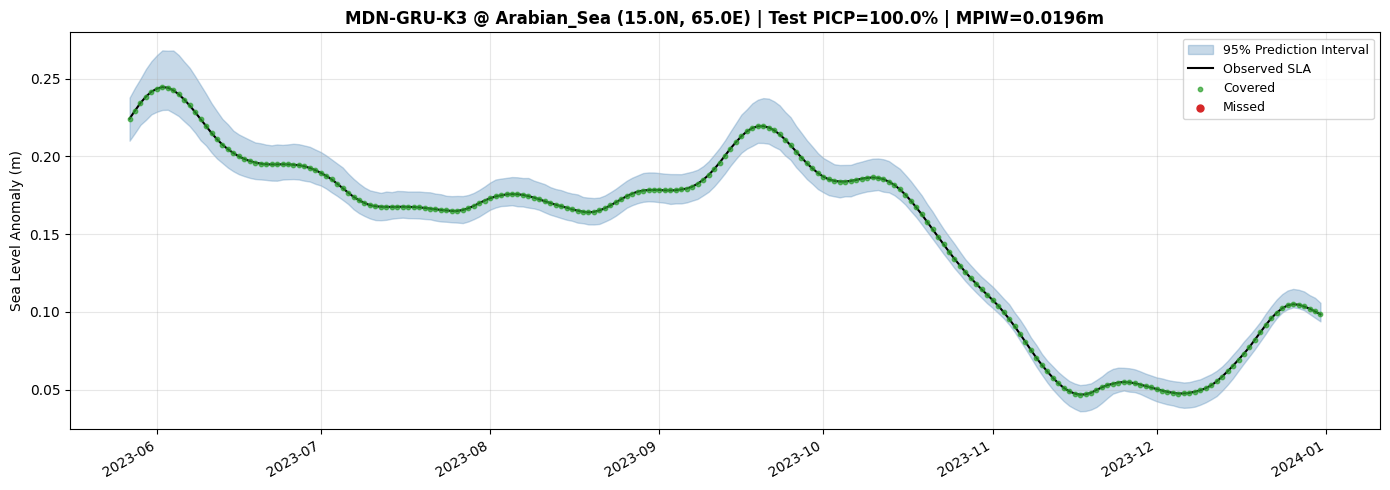

  Saved plot: c:\Users\DA IICT K\Desktop\BMP_files\results_IndianOcean/plot_MDN_Arabian_Sea.png


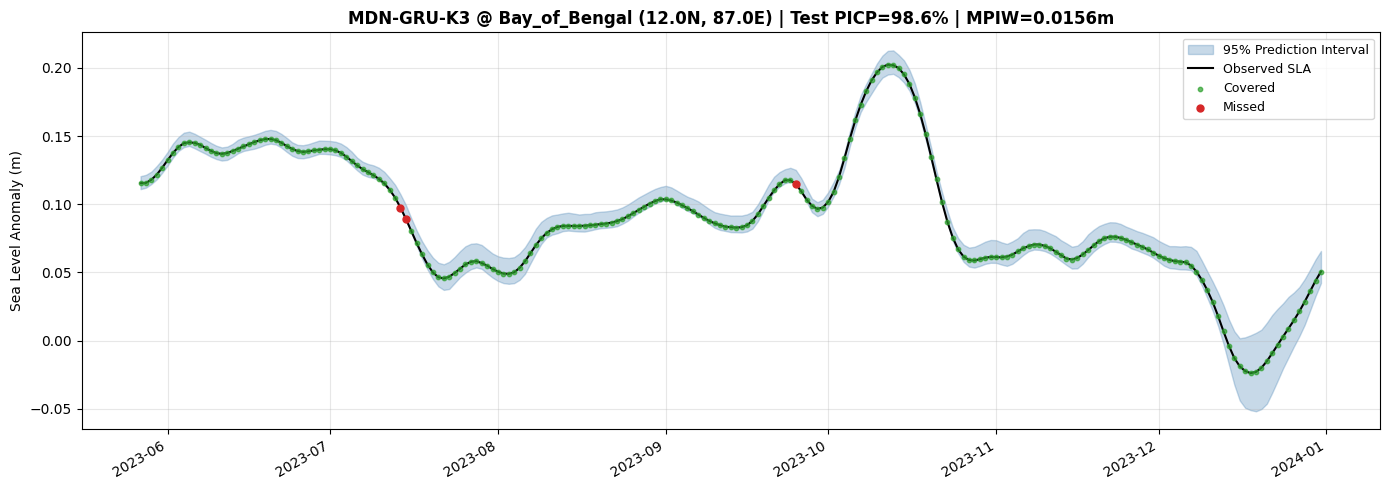

  Saved plot: c:\Users\DA IICT K\Desktop\BMP_files\results_IndianOcean/plot_MDN_Bay_of_Bengal.png


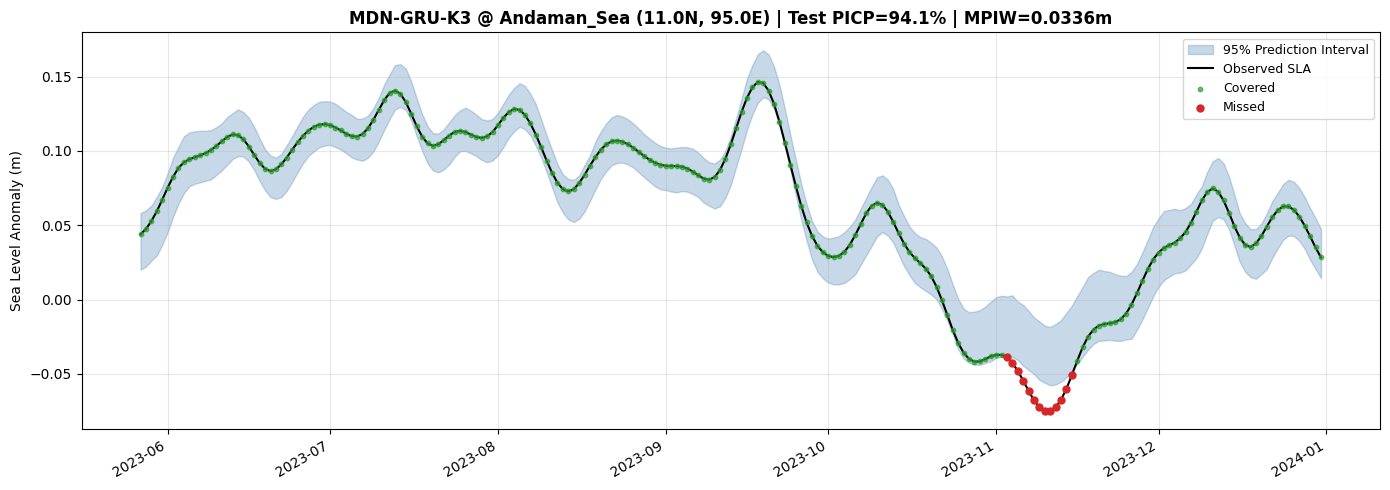

  Saved plot: c:\Users\DA IICT K\Desktop\BMP_files\results_IndianOcean/plot_MDN_Andaman_Sea.png


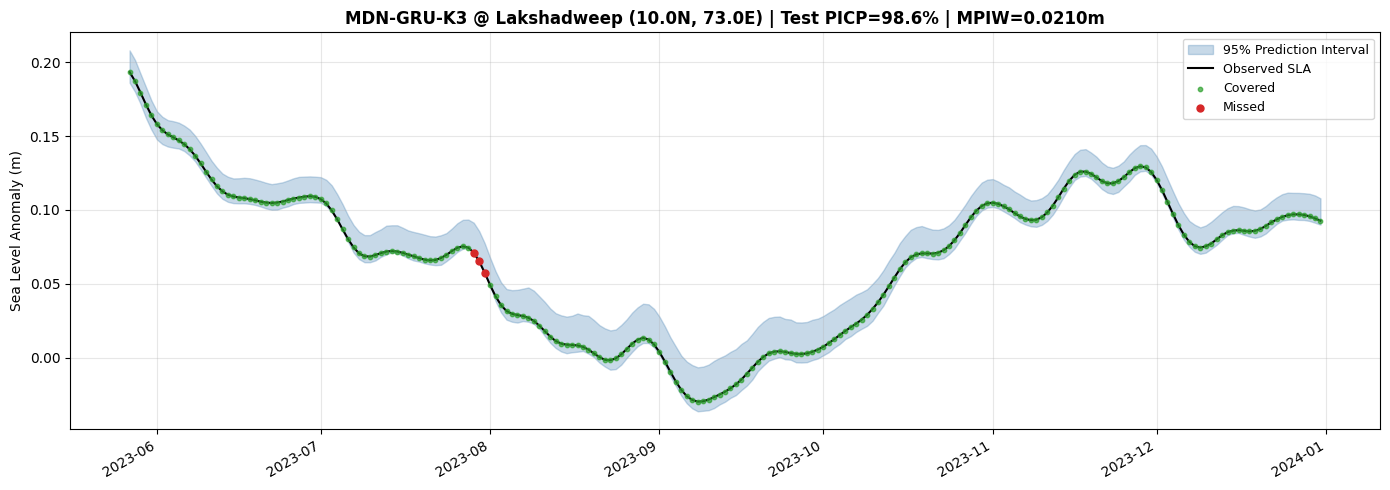

  Saved plot: c:\Users\DA IICT K\Desktop\BMP_files\results_IndianOcean/plot_MDN_Lakshadweep.png


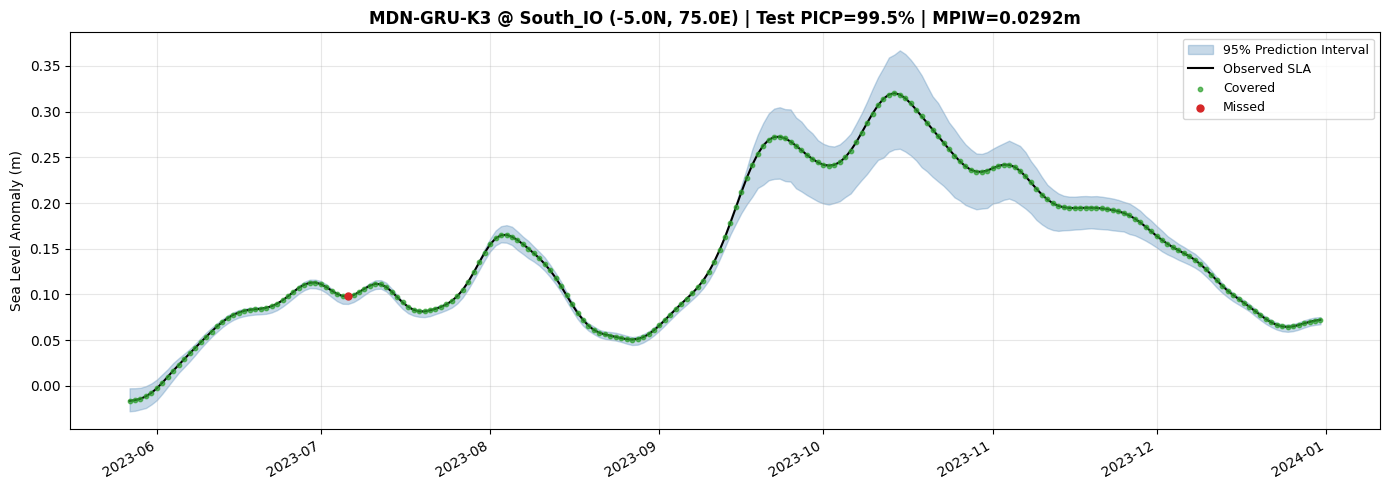

  Saved plot: c:\Users\DA IICT K\Desktop\BMP_files\results_IndianOcean/plot_MDN_South_IO.png


In [13]:
# ── Cell: Visualization of Prediction Intervals ────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import numpy as np

ARCH = 'MDN'

print(f'\n{"="*65}')
print(f'  Generating Forecast Plots for {ARCH}')
print(f'{"="*65}')

# Get the exact dates for the test set
test_dates = times_index[-n_test:] 

# We will plot the first seed (usually 42) for the visualizations
plot_seed = SEEDS[0]

for loc_name, (lat, lon) in LOCATIONS.items():
    if loc_name not in all_preds:
        continue
        
    model_keys = list(all_preds[loc_name].keys())
    fig, axes = plt.subplots(len(model_keys), 1, figsize=(14, 5 * len(model_keys)), squeeze=False)
    axes = axes.flatten()

    for idx, model_id in enumerate(model_keys):
        ax = axes[idx]
        
        if plot_seed not in all_preds[loc_name][model_id]:
            continue
            
        # Extract bounds and actual observed values
        lo, hi, y_m = all_preds[loc_name][model_id][plot_seed]
        
        # Calculate coverage for the title
        covered = (y_m >= lo) & (y_m <= hi)
        picp = np.mean(covered) * 100.0
        mpiw = np.mean(hi - lo)
        
        # Plot the confident envelope and the actual line
        ax.fill_between(test_dates, lo, hi, alpha=0.3, color='steelblue', label='95% Prediction Interval')
        ax.plot(test_dates, y_m, 'k-', lw=1.5, label='Observed SLA')
        
        # Scatter plot for visual proof of coverage
        ax.scatter(test_dates[covered], y_m[covered], color='#2ca02c', s=10, zorder=4, alpha=0.7, label='Covered')
        ax.scatter(test_dates[~covered], y_m[~covered], color='#d62728', s=25, zorder=5, label='Missed')
        
        # Professional formatting
        ax.set_title(f'{model_id} @ {loc_name} ({lat}N, {lon}E) | Test PICP={picp:.1f}% | MPIW={mpiw:.4f}m', fontsize=12, fontweight='bold')
        ax.set_ylabel('Sea Level Anomaly (m)', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right', fontsize=9)
        
        # Format the X-axis to show real dates beautifully
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    plt.tight_layout()
    fp = os.path.join(SAVE_DIR, f'plot_{ARCH}_{loc_name}.png')
    plt.savefig(fp, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'  Saved plot: {fp}')